In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
import requests
import pandas as pd

url = 'http://127.0.0.1:8000/'
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'}
response = requests.get('http://127.0.0.1:8000/analyses/', headers=headers)


<Axes: >

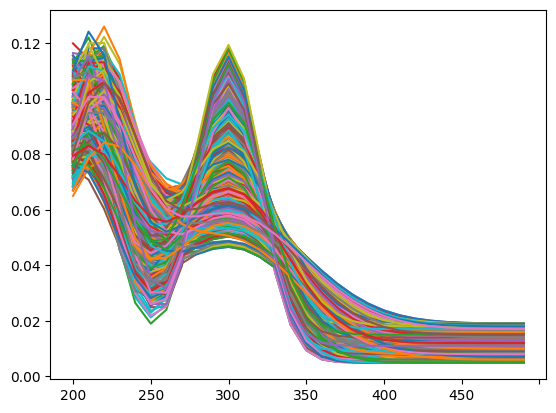

In [3]:
pd.DataFrame([pd.Series(a['Analyses_data'],name=a['Analyse_name']) for a in response.json() if a['Analyse_subname'] == 'UV']).T.plot(legend=False)

In [4]:
data_RAMAN = pd.DataFrame([pd.Series(a['Analyses_data'],name=a['Analyse_name']) for a in response.json() if a['Analyse_subname'] == 'RAMAN'])#.T.plot(legend=False)
data_UV = pd.DataFrame([pd.Series(a['Analyses_data'],name=a['Analyse_name']) for a in response.json() if a['Analyse_subname'] == 'UV'])#.T.plot(legend=False)

In [5]:
import numpy as np
from sklearn.decomposition import PCA


pca = PCA(n_components=3)
weights_RAMAN=pca.fit_transform(data_RAMAN.iloc[:,1:].fillna(0))
weights_UV=pca.fit_transform(data_UV.iloc[:,1:].fillna(0))

assert (data_RAMAN.index == data_UV.index).all()

weigths_analysis = np.concatenate([weights_RAMAN,weights_UV],axis=1)
weigths_analysis.shape

(607, 6)

In [6]:
# FastICA: a fast algorithm for Independent Component Analysis.

# from sklearn.datasets import load_digits
# from sklearn.decomposition import FastICA
# X, _ = load_digits(return_X_y=True)
# transformer = FastICA(n_components=7,
#         random_state=0,
#         whiten='unit-variance')
# X_transformed = transformer.fit_transform(X)
# X_transformed.shape

In [7]:
response = requests.get('http://127.0.0.1:8000/OGD/', headers=headers)


In [8]:
metadata = pd.DataFrame(response.json())
metadata.columns

assert (metadata.Batch_OGD_name == data_RAMAN.index).all()

time_columns = ['Batch_OGD_date','Batch_OGD_heure_debut','Batch_OGD_heure_fin']
categorical_columns = ['Batch_OGD_Technicien','Batch_OGD_KC8_batch','Batch_OGD_THF_batch']
numerical_columns = ['Batch_OGD_KC8_masse','Batch_OGD_Temperature','Batch_OGD_Agitation','Batch_OGD_room_HR','Batch_OGD_room_T']




data train XXXXXXXXxx   --> initialise the clusturing on first 80%  == KMeans model 1

data test  xxxxxxXXXX   --> test clusturing on last 40% == KMeans model 2


make score verif on 60->80% (rand score)

make score assess on 80->100% 


Silhouette Score (S) for a data point i is calculated as:
Interpretation: It ranges from -1 (poor clustering) to +1 (perfect clustering). A score close to 1 suggests well-separated clusters.

Davies-Bouldin Index (DB) is calculated as the average similarity between each cluster and its closest neighbor:
Interpretation: Lower numbers suggest better clustering solutions.

Calinski-Harabasz Index (CH) is calculated as:
Interpretation: Higher numbers suggest better-defined clusters.

Adjusted Rand Index (ARI) is calculated as:
Interpretation: It ranges from -1 to 1, where 1 indicates perfect clustering, 0 indicates random clustering, and negative values suggest poor clustering.

MI between true labels Y and predicted labels Z is calculated as:
Interpretation: High MI values indicate better alignment between clusters and true labels, signifying good clustering results.


In [9]:
# save data for python script for ml flow on azure

import pickle
with open('ML_Models/data/train.pkl', 'wb') as file: 
    pickle.dump(metadata.iloc[:120,2:], file) 
with open("ML_Models/data/test.pkl", 'wb') as file: 
    pickle.dump(metadata.iloc[40:,2:], file) 


In [10]:
# handeling time variables

timed = metadata[time_columns]
for col in timed.columns:
    timed.loc[:,col] = pd.to_datetime(timed[col])

timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
timed['time_exfo'] = (timed['Batch_OGD_heure_fin'] - timed['Batch_OGD_heure_debut']) / pd.Timedelta(hours=1)

metadata_timed = pd.concat([metadata,timed],axis=1)

numerical_columns = numerical_columns + ['time_exfo']
categorical_columns = categorical_columns + ['year','month']


/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_62658/2575082292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_62658/2575082292.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_62658/2575082292.py:9: SettingWithCopyWarning

In [11]:
# handeling numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(metadata_timed[numerical_columns])
scaled = pd.DataFrame(scaled)
scaled.columns = numerical_columns


In [12]:
# handeling categorical variables
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder( sparse_output=False)
ohe_data = ohe.fit_transform(metadata_timed[categorical_columns])
ohe_cols = [a for b in ohe.categories_ for a in b]
onehotencoded = pd.DataFrame(data=ohe_data,columns=ohe_cols)
# onehotencoded = pd.get_dummies(metadata_timed[categorical_columns],drop_first=True).reset_index(drop=True)

In [ ]:
metadata_ready = pd.concat([metadata['Batch_OGD_name'],scaled,onehotencoded],axis=1)
assert (metadata_ready.Batch_OGD_name == data_RAMAN.index).all()

df_analysis = pd.DataFrame(data=weigths_analysis,index=metadata_ready.Batch_OGD_name)
data_ready = pd.merge(df_analysis,metadata_ready,on='Batch_OGD_name')
data_ready.columns = data_ready.columns.astype(str)

# assess clustering

In [17]:
from sklearn.cluster import KMeans


from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mutual_info_score, adjusted_rand_score


clust_results = dict()
n_to_fit = round(data_ready.shape[0]*0.6)
n_to_test = round(data_ready.shape[0]*0.4)

for i in range(2,20):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:])
    clust_results[i] = dict()
    clust_results[i]['inertia'] = kmeans.inertia_
    clust_results[i]['silhouette'] = silhouette_score(data_ready.iloc[:,1:], kmeans.labels_)
    clust_results[i]['davies_bouldin'] = davies_bouldin_score(data_ready.iloc[:,1:], kmeans.labels_)
    clust_results[i]['calinski_harabasz'] = calinski_harabasz_score(data_ready.iloc[:,1:], kmeans.labels_)


    # check clusturing on part of data
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(data_ready.iloc[:n_to_fit,1:])
    preds = kmeans.predict(data_ready.iloc[-n_to_fit:,1:])

    # clust_results[i] = dict()
    clust_results[i]['mutual_info'] = mutual_info_score(kmeans.labels_[-n_to_test:], preds[:n_to_test])
    clust_results[i]['adjusted_rand'] = adjusted_rand_score(kmeans.labels_[-n_to_test:], preds[:n_to_test])

In [18]:
# train
print("train",data_ready.iloc[:n_to_fit,1:].shape)
# test
print("test_on_train",data_ready.iloc[:n_to_fit,1:][-n_to_test:].shape)

# predict
print("predict",data_ready.iloc[-n_to_fit:,1:].shape)
# test
print("test_on_predict",data_ready.iloc[-n_to_fit:,1:][:n_to_test].shape)

train (364, 657)
test_on_train (243, 657)
predict (364, 657)
test_on_predict (243, 657)


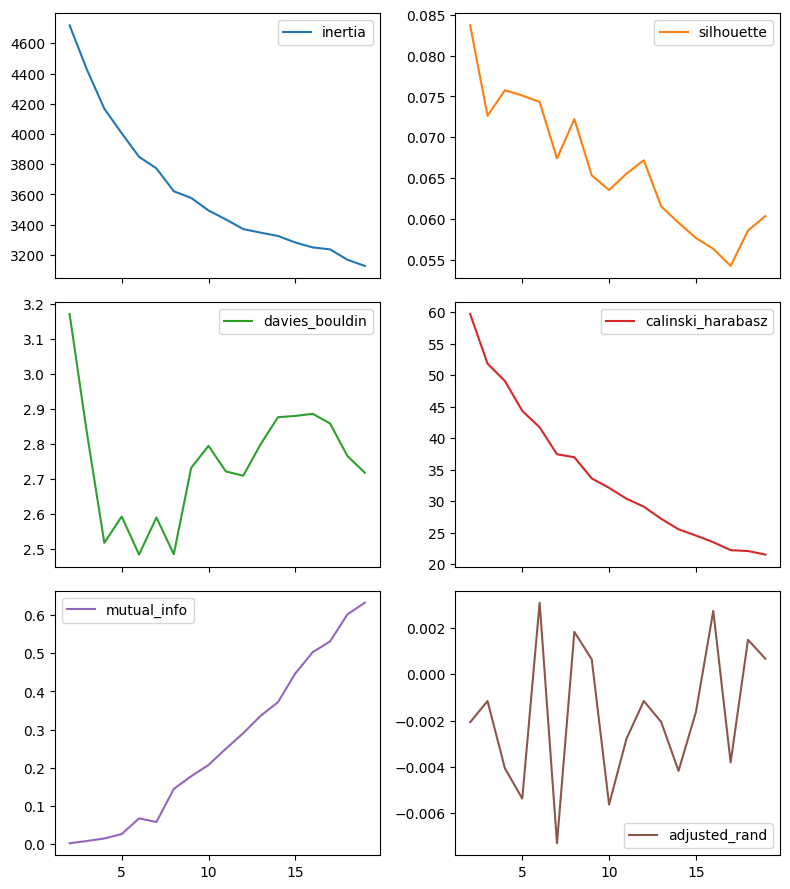

In [19]:
# PLOT results
clust_results = pd.DataFrame(clust_results).T
clust_results.plot(subplots=True,layout=(3,2),figsize=(8,9))
plt.tight_layout()

# create sample and localize it on the 2D map

In [26]:
# make sample

sample_name = 'OGD2501-D'
response = requests.get(f'http://127.0.0.1:8000/OGD/name/{sample_name}', headers=headers)
sample = pd.DataFrame(response.json(),index=[0])


sample_timed = sample[time_columns]
for col in time_columns:
    sample_timed.loc[:,col] = pd.to_datetime(sample_timed[col])

sample_timed['year'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).year.astype(str)
sample_timed['month'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).month.astype(str)
sample_timed['time_exfo'] = (sample_timed['Batch_OGD_heure_fin'] - sample_timed['Batch_OGD_heure_debut']) / pd.Timedelta(hours=1)

sample_metadata_timed = pd.concat([sample,sample_timed],axis=1)

sample_scaled = scaler.transform(sample_metadata_timed[numerical_columns])
sample_scaled = pd.DataFrame(scaled, columns=numerical_columns,index=[0])

sample_ohe_data = ohe.transform(sample_metadata_timed[categorical_columns])
sample_onehotencoded = pd.DataFrame(data=sample_ohe_data,columns=ohe_cols,index=[0])

sample_metadata_ready = pd.concat([sample['Batch_OGD_name'],sample_scaled,sample_onehotencoded],axis=1)
sample_metadata_ready

/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_62658/4089678676.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_timed['year'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).year.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_62658/4089678676.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_timed['month'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).month.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_62658/408967867

,Batch_OGD_name,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,...,11,12,2,3,4,5,6,7,8,9
0,OGD2501-D,0.0,1.191825,-1.097965,0.844097,1.254124,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
metadata_ready.iloc[:120,1:]
metadata_ready.iloc[40:,1:]

,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,TB,...,11,12,2,3,4,5,6,7,8,9
40,0.0,-1.277246,-1.097965,-1.661364,-1.158723,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
41,0.0,1.191825,-0.083559,-0.721816,0.047700,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
42,0.0,-1.277246,-1.097965,-1.034999,1.254124,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43,0.0,-0.042710,-1.097965,1.470462,0.047700,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
44,0.0,-1.277246,-1.097965,1.470462,-1.158723,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,0.0,-1.277246,-1.097965,-0.095451,0.047700,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
603,0.0,-0.042710,-1.097965,-1.034999,1.254124,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
604,0.0,-1.277246,-1.097965,-1.348181,1.254124,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
605,0.0,-0.042710,-1.097965,-0.721816,1.254124,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


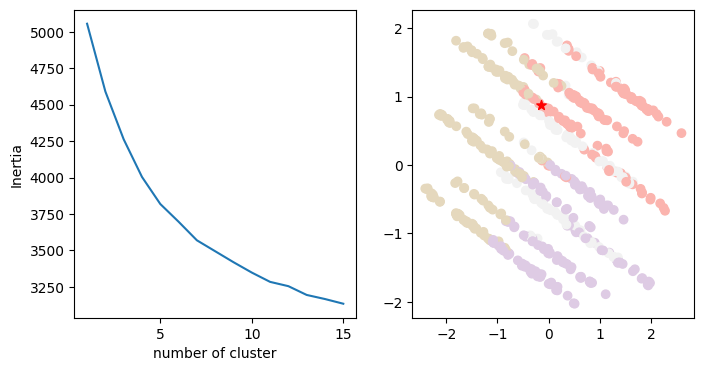

In [27]:
from sklearn.cluster import KMeans
import numpy as np

import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
weights=pca.fit_transform(metadata_ready.iloc[:,1:].fillna(0))
sample_weights = pca.transform(sample_metadata_ready.iloc[:,1:])
inertias=list()
for i in range(1,16):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(metadata_ready.iloc[:,1:].fillna(0))
    inertias.append(kmeans.inertia_)

kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(metadata_ready.iloc[:,1:].fillna(0))


f, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(range(1,16),inertias)
ax[0].set_xlabel("number of cluster")
ax[0].set_ylabel("Inertia")
ax[1].scatter(weights[:,0],weights[:,1],c=kmeans.labels_,cmap='Pastel1')
ax[1].scatter(sample_weights[:,0],sample_weights[:,1],c='red',s=50,marker='*')

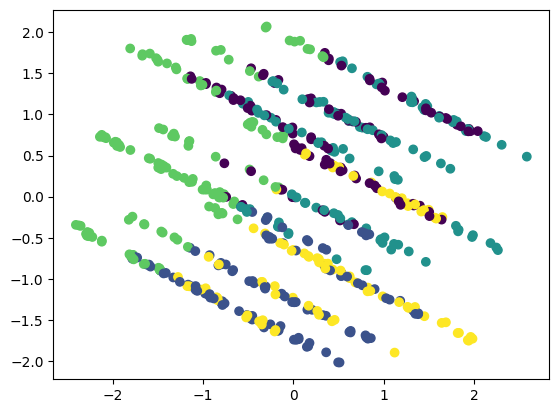

In [30]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:])
pca = PCA(n_components=5)
w=pca.fit_transform(data_ready.iloc[:,1:])
plt.scatter(w[:,0],w[:,1],c=kmeans.labels_, cmap='viridis')

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
w=pca.fit_transform(data)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
import joblib
joblib.dump(pca, "save_on_cloud_pca.joblib")

[0.44681312 0.26109155 0.17818928 0.10255493 0.00820249]
[0.13224742 0.1010929  0.08351511 0.06335816 0.01791831]


['save_on_cloud_pca.joblib']

In [ ]:
from scipy import stats 
import matplotlib.pyplot as plt

def make_curve():
    # Generate the data
    array1 = stats.norm.pdf(range(10, 40), random.choice(np.arange(10,12,0.2)), random.choice(np.arange(2,3,0.1)))
    array2 = stats.norm.pdf(range(30), 10, random.choice(np.arange(2,5,0.2)))

    # Reshape the arrays to 2D (add an extra axis)
    array1 = array1.reshape(1, -1)  # Shape: (1, n)
    array2 = array2.reshape(1, -1)  # Shape: (1, n)

    # Concatenate along axis=1
    result = np.concatenate([array1, array2]).T
    return result.mean(axis=1)

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import random


kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(data)

joblib.dump(kmeans.labels_, "save_on_cloud_kmean_label.joblib")

test = (make_curve().reshape(1, -1))
p=kmeans.predict(test)
c=pca.transform(test)
kmeans.cluster_centers_

/Applications/anaconda3/envs/CarbonWaters/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
/Applications/anaconda3/envs/CarbonWaters/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([[0.10358911, 0.10636443, 0.09503926, 0.07729556, 0.06205499,
        0.05384312, 0.05229916, 0.05476122, 0.05848219, 0.06146356,
        0.06252382, 0.06119152, 0.05758408, 0.05225098, 0.04597096,
        0.03953951, 0.03360095, 0.02856098, 0.02458179, 0.02163444,
        0.01957373, 0.01820749, 0.01734569, 0.01682733, 0.01652959,
        0.01636614, 0.01628034, 0.01623726, 0.01621657, 0.01620707],
       [0.08041572, 0.08937484, 0.08717785, 0.07558861, 0.06135213,
        0.05175482, 0.05059138, 0.05720746, 0.06773418, 0.07696399,
        0.08039216, 0.07603209, 0.06508845, 0.05097568, 0.03737285,
        0.026649  , 0.01944818, 0.01522165, 0.01300688, 0.01195036,
        0.01148316, 0.01128866, 0.01121163, 0.01118247, 0.01117194,
        0.01116833, 0.01116716, 0.0111668 , 0.0111667 , 0.01116667],
       [0.08470002, 0.09060816, 0.08495887, 0.07194654, 0.05853043,
        0.04987237, 0.04729192, 0.04919607, 0.05295418, 0.05618876,
        0.05730448, 0.05559945, 0.05118293, 0.

In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=3, min_samples=2).fit_predict(data)

test = (make_curve().reshape(1, -1))
# db_group=dbscan.predict(test)
dbscan

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

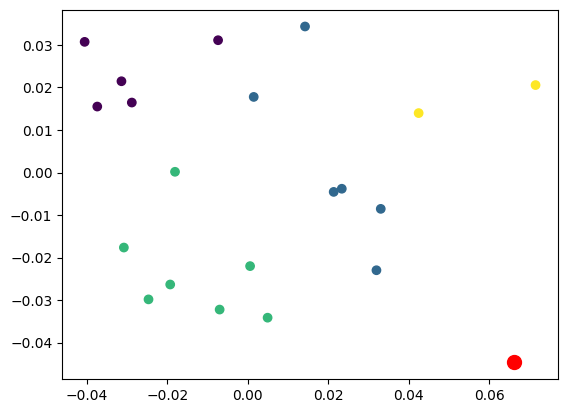

In [ ]:
import matplotlib.pyplot as plt
# plt.plot(pca.explained_variance_ratio_.cumsum())
plt.scatter(w[:,0],w[:,1],c=kmeans.labels_)
plt.scatter(c[:,0],c[:,1],c='red',s=100)


In [ ]:

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN


from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mutual_info_score, adjusted_rand_score


